# 1. Análise Exploratória de Dados (EDA) — Flight Delays

**Tech Challenge Fase 3 — Machine Learning Engineering**

Este notebook realiza a exploração completa do dataset de voos domésticos dos EUA (2015), incluindo:
- Estatísticas descritivas e visão geral da estrutura dos dados
- Tratamento e verificação de valores ausentes
- Distribuição da variável alvo (atraso ≥ 15 min)
- Análises por companhia aérea, aeroporto, horário e sazonalidade
- Matriz de correlação e identificação de outliers
- Composição dos tipos de atraso
- Insights e conclusões para guiar a modelagem

## 1.1 Importar Bibliotecas e Carregar Dados

Importamos as bibliotecas essenciais e utilizamos os módulos `data_loader` e `feature_engineering` do projeto para carregar, limpar e enriquecer os dados.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

from src.data_loader import load_clean_data
from src.feature_engineering import prepare_features

In [2]:
flights, airlines, airports = load_clean_data()
flights = prepare_features(flights)

print(f"Total de voos (após limpeza): {flights.shape[0]:,}")
print(f"Total de colunas: {flights.shape[1]}")
print(f"Período: {flights['FL_DATE'].min().date()} a {flights['FL_DATE'].max().date()}")
print(f"\nCompanhias aéreas: {flights['AIRLINE'].nunique()}")
print(f"Aeroportos de origem: {flights['ORIGIN_AIRPORT'].nunique()}")
print(f"Aeroportos de destino: {flights['DESTINATION_AIRPORT'].nunique()}")

Total de voos (após limpeza): 5,714,008
Total de colunas: 51
Período: 2015-01-01 a 2015-12-31

Companhias aéreas: 14


Aeroportos de origem: 628
Aeroportos de destino: 629


## 1.2 Visão Geral dos Dados (Shape, Tipos e Info)

Vamos entender a estrutura dos dados, tipos de variáveis e identificar possíveis problemas.

In [3]:
flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 5714008 entries, 0 to 5714007
Data columns (total 51 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   YEAR                      int64         
 1   MONTH                     int64         
 2   DAY                       int64         
 3   DAY_OF_WEEK               int64         
 4   AIRLINE                   str           
 5   FLIGHT_NUMBER             int64         
 6   TAIL_NUMBER               str           
 7   ORIGIN_AIRPORT            str           
 8   DESTINATION_AIRPORT       str           
 9   SCHEDULED_DEPARTURE       int64         
 10  DEPARTURE_TIME            float64       
 11  DEPARTURE_DELAY           float64       
 12  TAXI_OUT                  float64       
 13  WHEELS_OFF                float64       
 14  SCHEDULED_TIME            float64       
 15  ELAPSED_TIME              float64       
 16  AIR_TIME                  float64       
 17  DISTANCE           

In [4]:
flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,DEST_LON,PERIODO_DIA,DEP_HOUR,ESTACAO,IS_WEEKEND,IS_HOLIDAY,NEAR_HOLIDAY,FLIGHTS_SAME_HOUR_ORIGIN,ROUTE_POPULARITY,IS_DELAYED
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,-122.30931,madrugada,0,inverno,0,1,1,4,6348,0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,-80.09559,madrugada,0,inverno,0,1,1,4,77,0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,-80.94313,madrugada,0,inverno,0,1,1,4,1811,0
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,-80.29056,madrugada,0,inverno,0,1,1,4,3002,0
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,-149.99619,madrugada,0,inverno,0,1,1,2,6357,0


## 1.3 Estatísticas Descritivas

Resumo estatístico das variáveis numéricas (média, desvio padrão, quartis, min, max).

In [5]:
flights.describe().round(2)

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,ORIGIN_LON,DEST_LAT,DEST_LON,DEP_HOUR,IS_WEEKEND,IS_HOLIDAY,NEAR_HOLIDAY,FLIGHTS_SAME_HOUR_ORIGIN,ROUTE_POPULARITY,IS_DELAYED
count,5714008.0,5714008.00,5714008.00,5714008.00,5714008.00,5714008.00,5714008.00,5714008.00,5714008.00,5714008.00,...,5226569.00,5226561.00,5226561.00,5714008.00,5714008.00,5714008.00,5714008.00,5714008.00,5714008.00,5714008.00
mean,2015.0,6.55,15.71,3.93,2164.38,1328.91,1335.07,9.29,16.07,1357.10,...,-95.57,36.62,-95.57,13.02,0.26,0.02,0.07,22.65,2532.17,0.19
min,2015.0,1.00,1.00,1.00,1.00,1.00,1.00,-82.00,1.00,1.00,...,-176.65,13.48,-176.65,0.00,0.00,0.00,0.00,1.00,1.00,0.00
25%,2015.0,4.00,8.00,2.00,728.00,916.00,921.00,-5.00,11.00,935.00,...,-111.98,32.90,-111.98,9.00,0.00,0.00,0.00,6.00,865.00,0.00
50%,2015.0,7.00,16.00,4.00,1681.00,1325.00,1330.00,-2.00,14.00,1343.00,...,-90.26,37.24,-90.26,13.00,0.00,0.00,0.00,17.00,1915.00,0.00
75%,2015.0,9.00,23.00,6.00,3211.00,1730.00,1740.00,7.00,19.00,1754.00,...,-81.69,40.79,-81.69,17.00,1.00,0.00,0.00,32.00,3521.00,0.00
max,2015.0,12.00,31.00,7.00,9320.00,2359.00,2400.00,1988.00,225.00,2400.00,...,-64.80,71.29,-64.80,23.00,1.00,1.00,1.00,104.00,13400.00,1.00
std,0.0,3.40,8.77,1.99,1754.71,483.53,496.42,36.89,8.88,498.02,...,18.19,6.01,18.19,4.82,0.44,0.16,0.25,20.52,2256.18,0.39


## 1.4 Verificar Valores Nulos e Duplicados

Verificamos a quantidade e percentual de valores nulos por coluna, além de registros duplicados.

In [6]:
# Valores nulos
null_counts = flights.isnull().sum()
null_pct = (null_counts / len(flights) * 100).round(2)
null_df = pd.DataFrame({"Nulos": null_counts, "% do Total": null_pct})
print("=== Colunas com Valores Nulos ===")
display(null_df[null_df["Nulos"] > 0].sort_values("Nulos", ascending=False))

# Duplicados
n_dup = flights.duplicated().sum()
print(f"\nRegistros duplicados: {n_dup:,}")

=== Colunas com Valores Nulos ===


,Nulos,% do Total
DEST_LON,487447,8.53
DEST_LAT,487447,8.53
ORIGIN_LAT,487439,8.53
ORIGIN_LON,487439,8.53
ORIGIN_CITY,482878,8.45
ORIGIN_AIRPORT_NAME,482878,8.45
DEST_AIRPORT_NAME,482878,8.45
ORIGIN_STATE,482878,8.45
DEST_STATE,482878,8.45
DEST_CITY,482878,8.45



Registros duplicados: 0


## 1.5 Distribuição da Variável Alvo

Definimos como **voo atrasado** aquele com `ARRIVAL_DELAY >= 15 minutos`. Vamos analisar a distribuição do atraso e a proporção de voos atrasados vs. no horário.

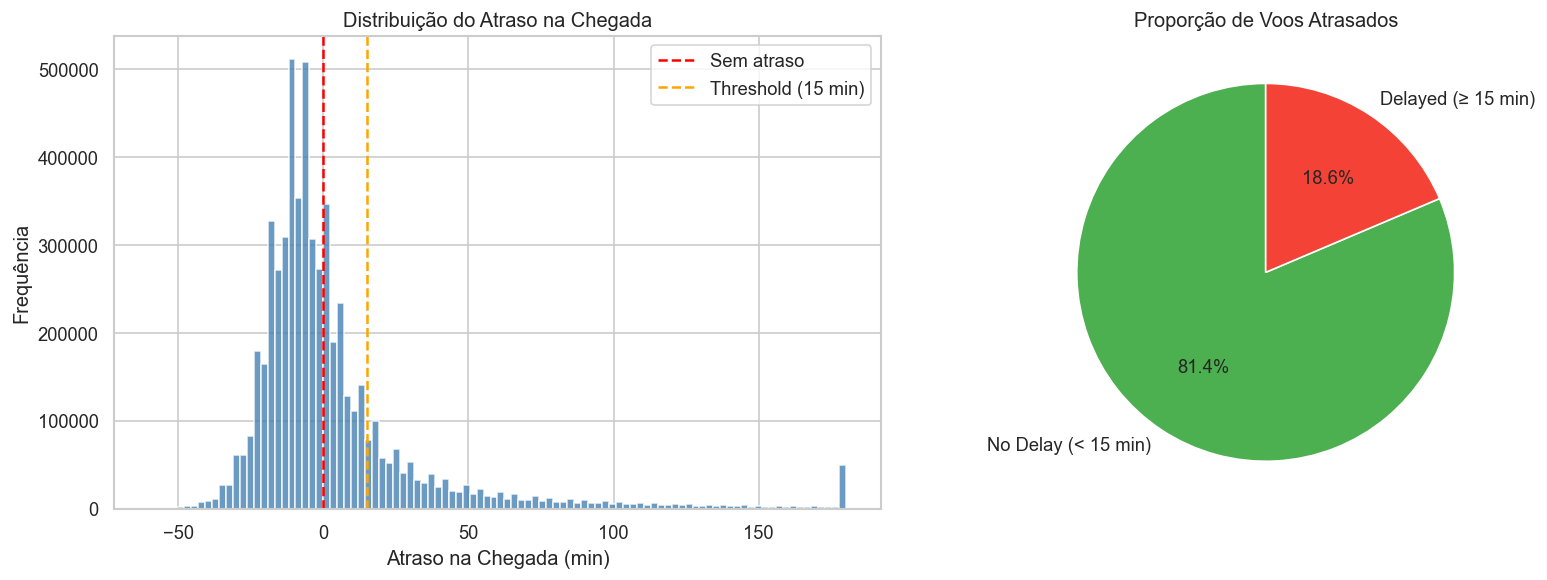

Voos no horário: 4,650,569 (81.4%)
Voos atrasados:  1,063,439 (18.6%)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de atrasos (clippado para melhor visualização)
delay_clipped = flights["ARRIVAL_DELAY"].clip(-60, 180)
axes[0].hist(delay_clipped, bins=100, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Sem atraso")
axes[0].axvline(15, color="orange", linestyle="--", linewidth=1.5, label="Threshold (15 min)")
axes[0].set_xlabel("Atraso na Chegada (min)")
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição do Atraso na Chegada")
axes[0].legend()

# Proporção de voos atrasados
delayed_counts = flights["IS_DELAYED"].value_counts()
labels = ["No Delay (< 15 min)", "Delayed (≥ 15 min)"]
colors = ["#4CAF50", "#F44336"]
axes[1].pie(delayed_counts, labels=labels, autopct="%1.1f%%", colors=colors,
            startangle=90, textprops={"fontsize": 11})
axes[1].set_title("Proporção de Voos Atrasados")

plt.tight_layout()
plt.savefig("../outputs/figures/eda_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Voos no horário: {delayed_counts[0]:,} ({delayed_counts[0]/len(flights)*100:.1f}%)")
print(f"Voos atrasados:  {delayed_counts[1]:,} ({delayed_counts[1]/len(flights)*100:.1f}%)")

## 1.6 Distribuição de Variáveis Numéricas Principais

Histogramas das variáveis numéricas-chave para entender a forma da distribuição, assimetrias e presença de outliers.

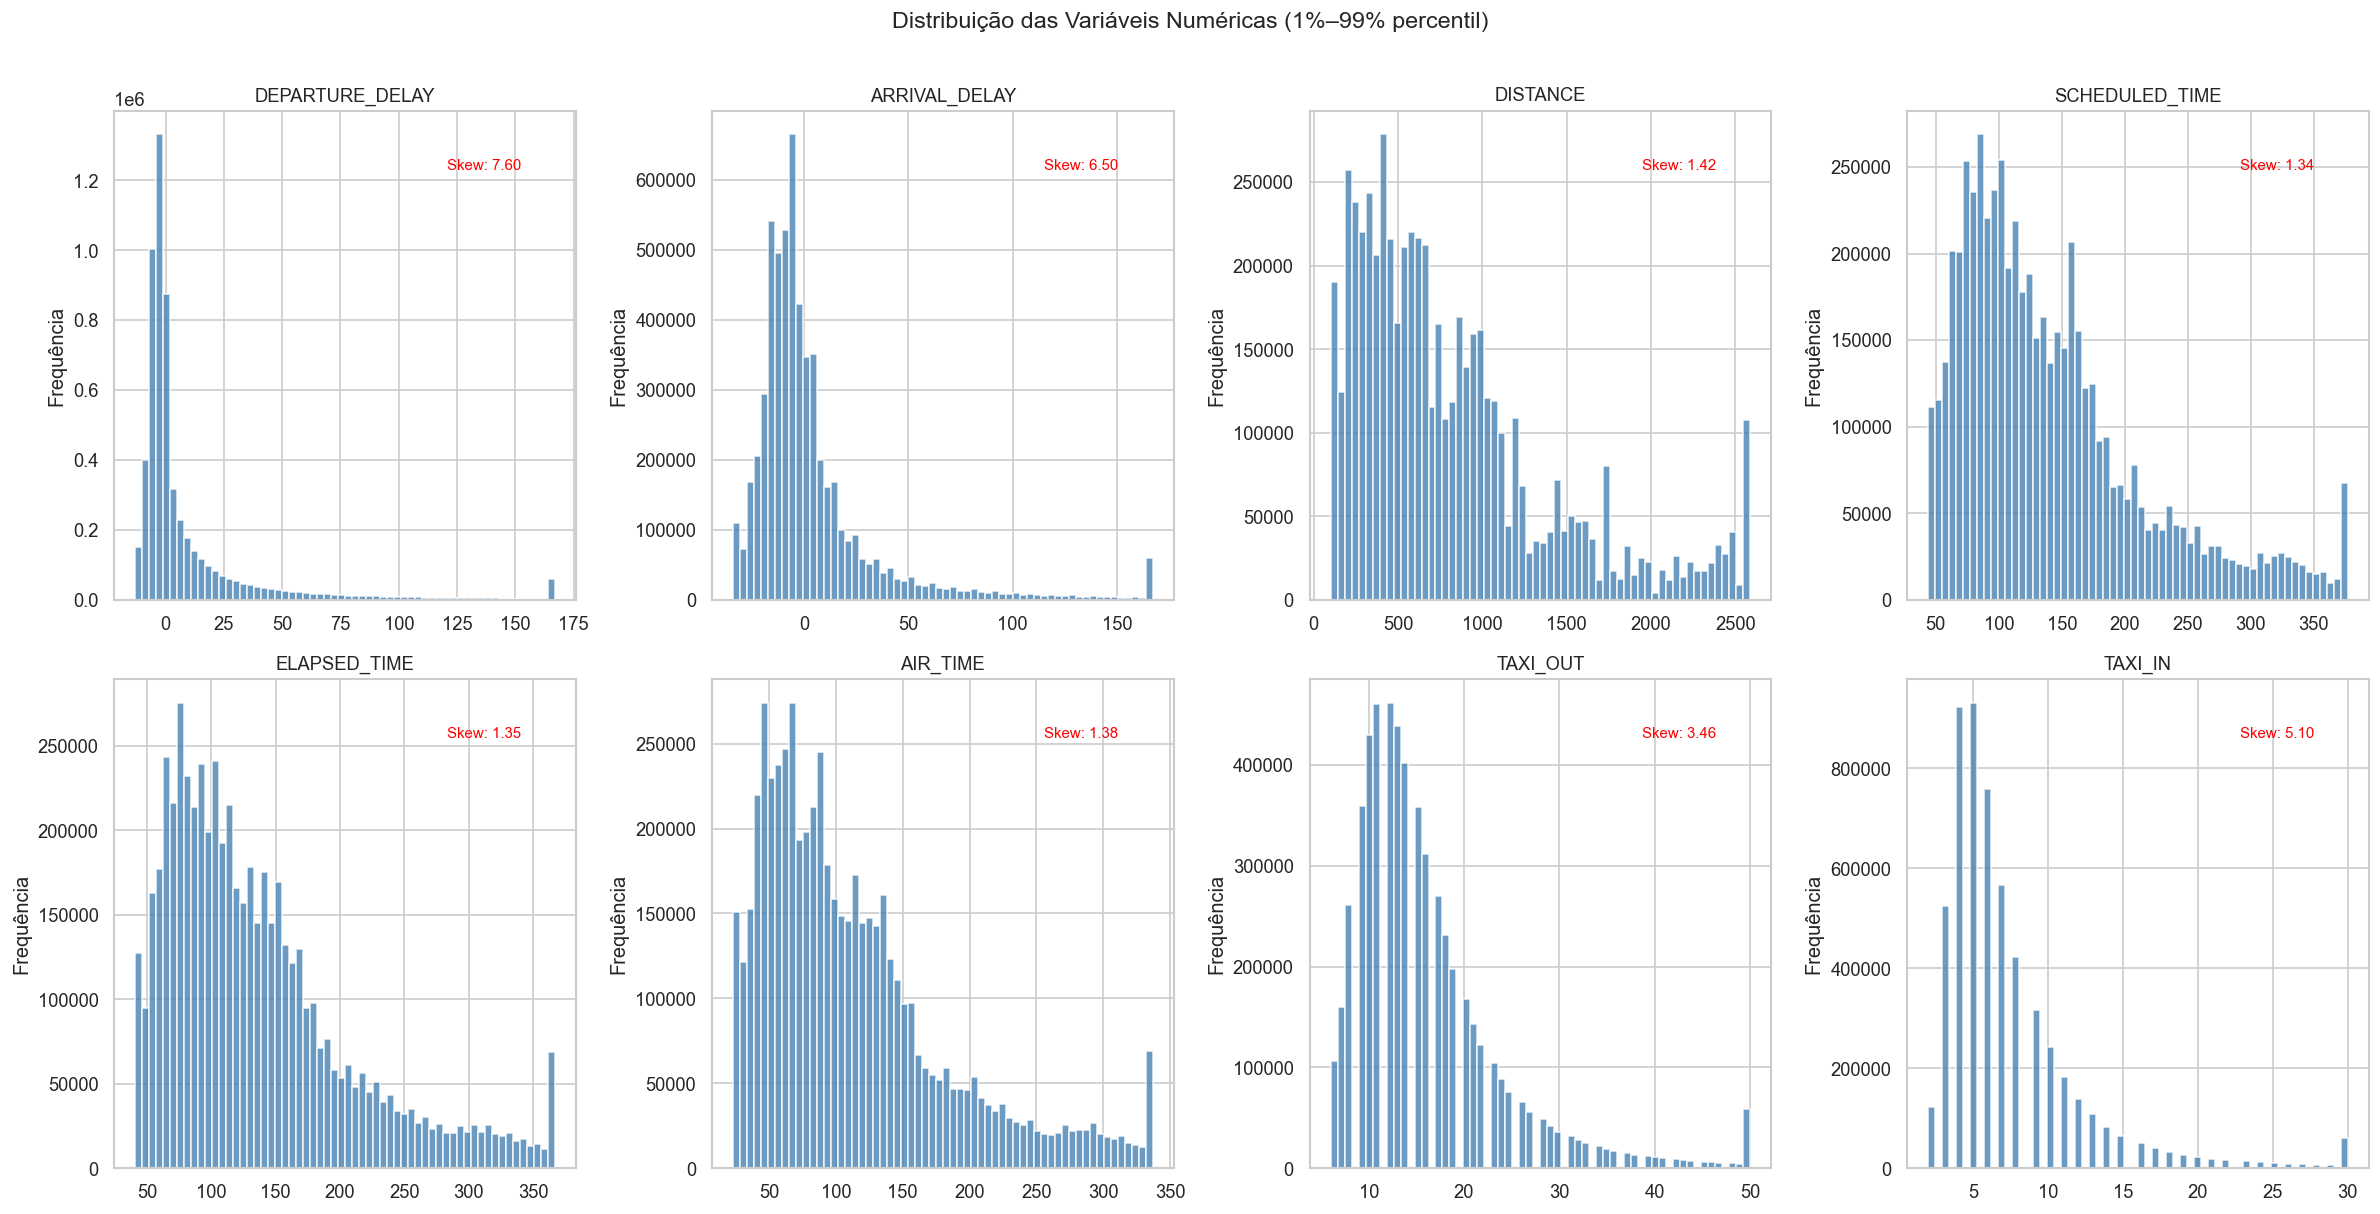

In [8]:
num_cols = ["DEPARTURE_DELAY", "ARRIVAL_DELAY", "DISTANCE", "SCHEDULED_TIME",
            "ELAPSED_TIME", "AIR_TIME", "TAXI_OUT", "TAXI_IN"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = flights[col].dropna()
    axes[i].hist(data.clip(data.quantile(0.01), data.quantile(0.99)),
                 bins=60, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel("Frequência")
    skew = data.skew()
    axes[i].annotate(f"Skew: {skew:.2f}", xy=(0.72, 0.88),
                     xycoords="axes fraction", fontsize=9, color="red")

plt.suptitle("Distribuição das Variáveis Numéricas (1%–99% percentil)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/figures/eda_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 1.7 Atrasos por Companhia Aérea

Quais companhias aéreas apresentam maior índice e média de atraso?

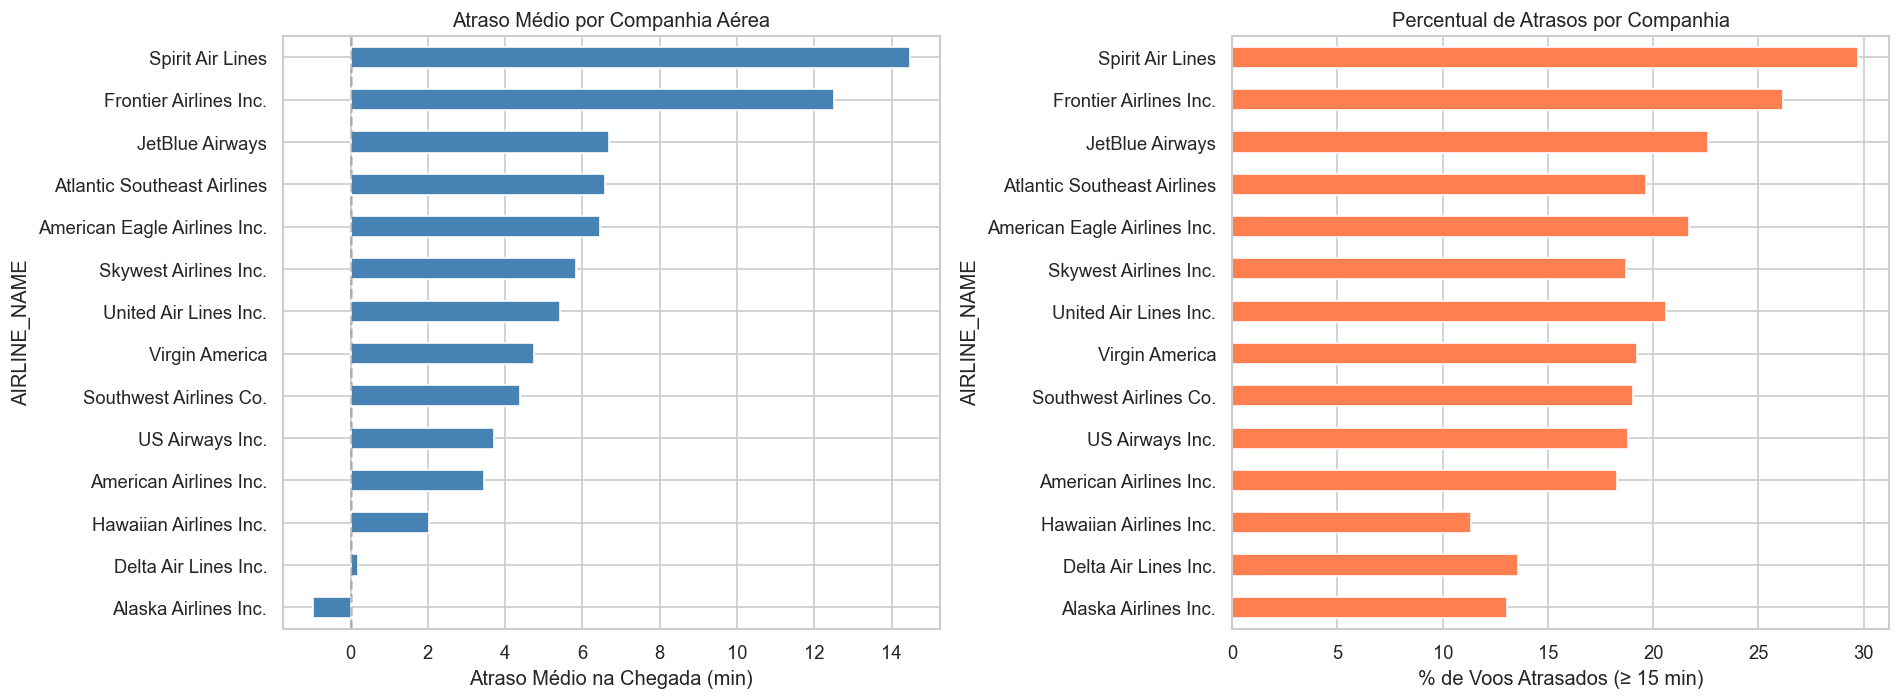


Resumo por Companhia Aérea:
                              Atraso Médio (min)  % Atrasados  Total Voos
AIRLINE_NAME                                                             
Spirit Air Lines                       14.471800         29.7      115193
Frontier Airlines Inc.                 12.504706         26.2       90090
JetBlue Airways                         6.677861         22.6      262042
American Eagle Airlines Inc.            6.457873         21.7      278791
United Air Lines Inc.                   5.431594         20.6      507762
Atlantic Southeast Airlines             6.585379         19.7      554752
Virgin America                          4.737706         19.2       61248
Southwest Airlines Co.                  4.374964         19.0     1242403
US Airways Inc.                         3.706209         18.8      194223
Skywest Airlines Inc.                   5.845652         18.7      576814
American Airlines Inc.                  3.451372         18.3      712935
Delta Air

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

airline_stats = flights.groupby("AIRLINE_NAME").agg(
    media_atraso=("ARRIVAL_DELAY", "mean"),
    pct_atrasados=("IS_DELAYED", "mean"),
    total_voos=("FLIGHT_NUMBER", "count"),
).sort_values("media_atraso", ascending=True)

# Atraso médio
airline_stats["media_atraso"].plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_xlabel("Atraso Médio na Chegada (min)")
axes[0].set_title("Atraso Médio por Companhia Aérea")
axes[0].axvline(0, color="gray", linestyle="--", alpha=0.5)

# % de voos atrasados
(airline_stats["pct_atrasados"] * 100).plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_xlabel("% de Voos Atrasados (≥ 15 min)")
axes[1].set_title("Percentual de Atrasos por Companhia")

plt.tight_layout()
plt.savefig("../outputs/figures/eda_airlines.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nResumo por Companhia Aérea:")
summary = airline_stats.copy()
summary["pct_atrasados"] = (summary["pct_atrasados"] * 100).round(1)
summary.columns = ["Atraso Médio (min)", "% Atrasados", "Total Voos"]
print(summary.sort_values("% Atrasados", ascending=False).to_string())

## 1.8 Aeroportos Mais Críticos

Quais aeroportos de origem concentram os maiores (e menores) atrasos? Filtramos por aeroportos com pelo menos 5.000 voos para robustez estatística.

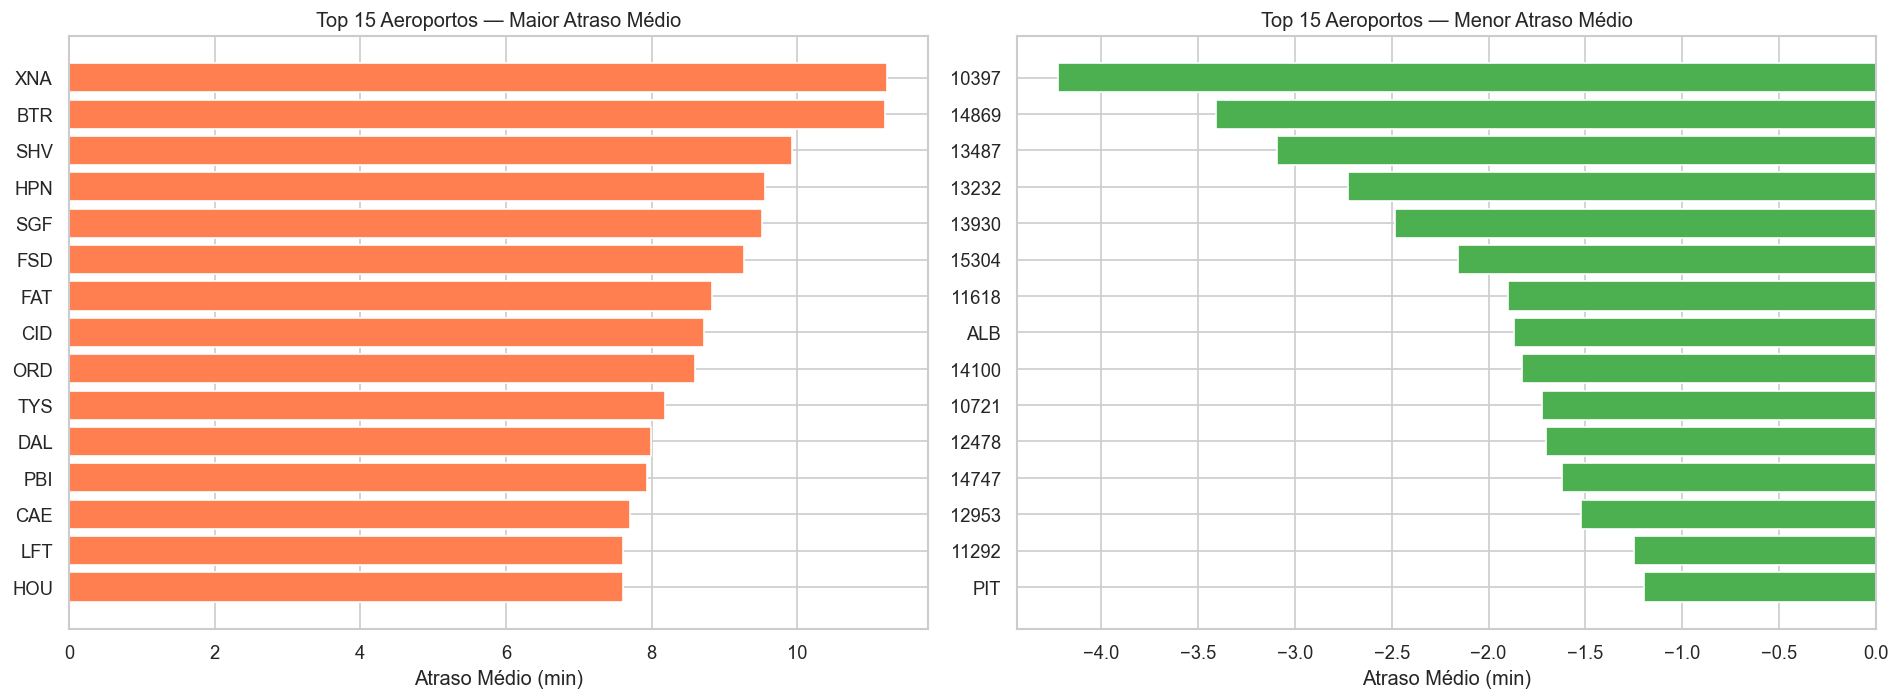

In [10]:
airport_stats = (
    flights.groupby("ORIGIN_AIRPORT")
    .agg(
        media_atraso=("ARRIVAL_DELAY", "mean"),
        pct_atrasados=("IS_DELAYED", "mean"),
        total_voos=("FLIGHT_NUMBER", "count"),
    )
    .query("total_voos >= 5000")
    .sort_values("media_atraso", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 piores
top15 = airport_stats.head(15)
axes[0].barh(top15.index[::-1], top15["media_atraso"].values[::-1], color="coral")
axes[0].set_xlabel("Atraso Médio (min)")
axes[0].set_title("Top 15 Aeroportos — Maior Atraso Médio")

# Top 15 melhores
bottom15 = airport_stats.tail(15)
axes[1].barh(bottom15.index, bottom15["media_atraso"].values, color="#4CAF50")
axes[1].set_xlabel("Atraso Médio (min)")
axes[1].set_title("Top 15 Aeroportos — Menor Atraso Médio")

plt.tight_layout()
plt.savefig("../outputs/figures/eda_airports.png", dpi=150, bbox_inches="tight")
plt.show()

## 1.9 Padrões Temporais

Investigamos se atrasos variam por **dia da semana**, **hora do dia** e **mês do ano**.

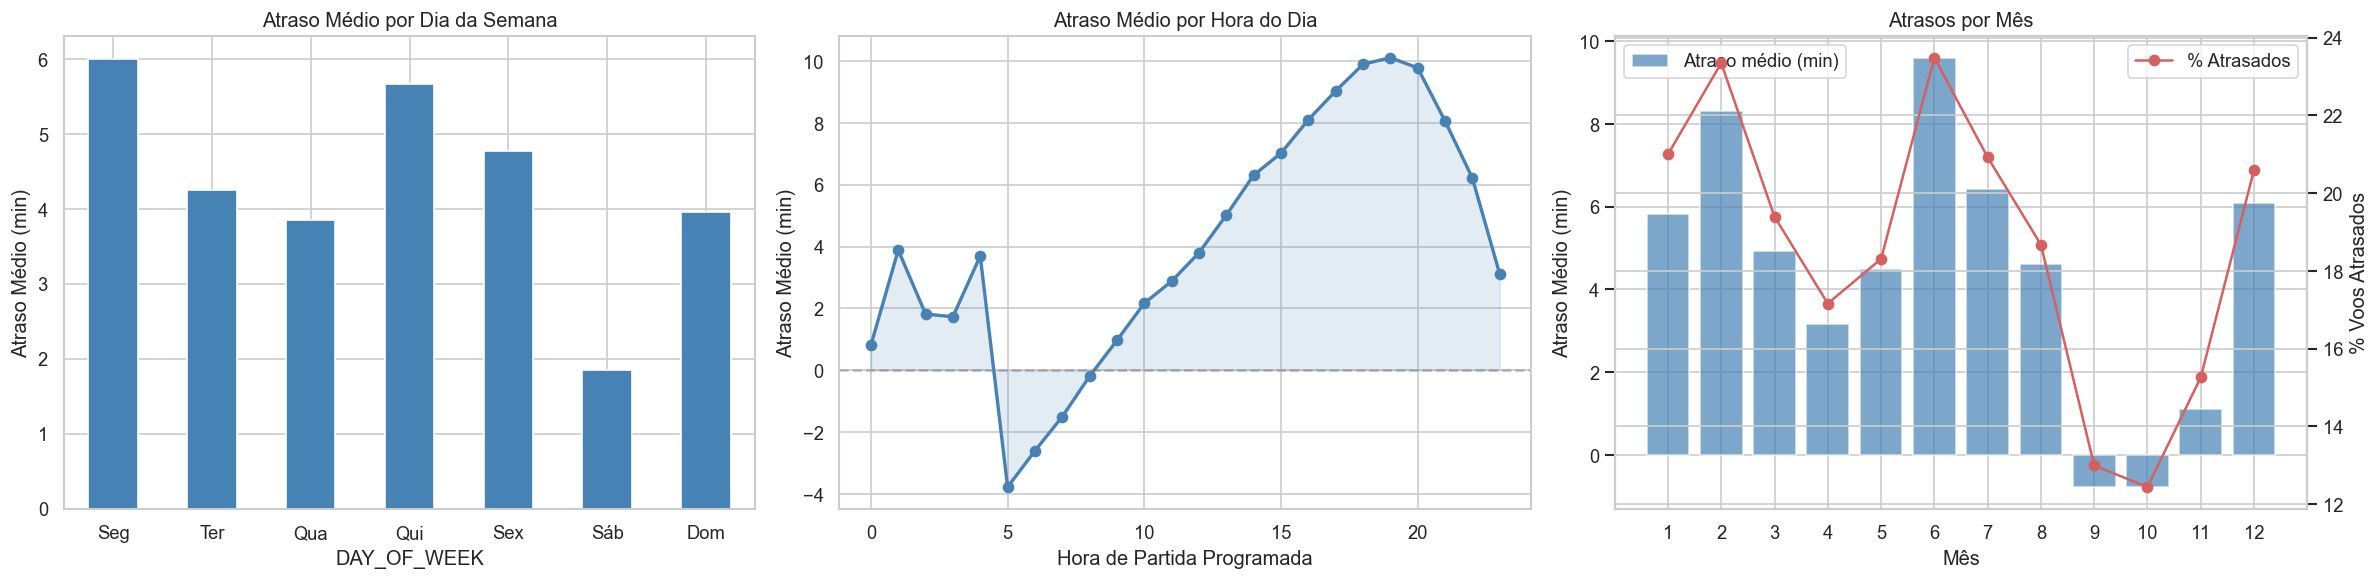

In [11]:
day_map = {1: "Seg", 2: "Ter", 3: "Qua", 4: "Qui", 5: "Sex", 6: "Sáb", 7: "Dom"}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Atraso por dia da semana
day_delay = flights.groupby("DAY_OF_WEEK")["ARRIVAL_DELAY"].mean()
day_delay.index = day_delay.index.map(day_map)
day_delay.plot(kind="bar", ax=axes[0], color="steelblue", rot=0)
axes[0].set_ylabel("Atraso Médio (min)")
axes[0].set_title("Atraso Médio por Dia da Semana")
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.5)

# 2) Atraso por hora do dia
hour_delay = flights.groupby("DEP_HOUR")["ARRIVAL_DELAY"].mean()
axes[1].plot(hour_delay.index, hour_delay.values, "o-", color="steelblue", linewidth=2)
axes[1].fill_between(hour_delay.index, hour_delay.values, alpha=0.15, color="steelblue")
axes[1].set_xlabel("Hora de Partida Programada")
axes[1].set_ylabel("Atraso Médio (min)")
axes[1].set_title("Atraso Médio por Hora do Dia")
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.5)

# 3) Atraso por mês
month_delay = flights.groupby("MONTH").agg(
    media=("ARRIVAL_DELAY", "mean"),
    pct_atrasados=("IS_DELAYED", "mean"),
)
axes[2].bar(month_delay.index, month_delay["media"], color="steelblue", alpha=0.7, label="Atraso médio (min)")
ax2 = axes[2].twinx()
ax2.plot(month_delay.index, month_delay["pct_atrasados"] * 100, "ro-", label="% Atrasados")
axes[2].set_xlabel("Mês")
axes[2].set_ylabel("Atraso Médio (min)")
ax2.set_ylabel("% Voos Atrasados")
axes[2].set_title("Atrasos por Mês")
axes[2].legend(loc="upper left")
ax2.legend(loc="upper right")
axes[2].set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig("../outputs/figures/eda_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

### Heatmap: Dia da Semana × Hora de Partida

Visualização bidimensional para identificar os momentos mais críticos para atrasos.

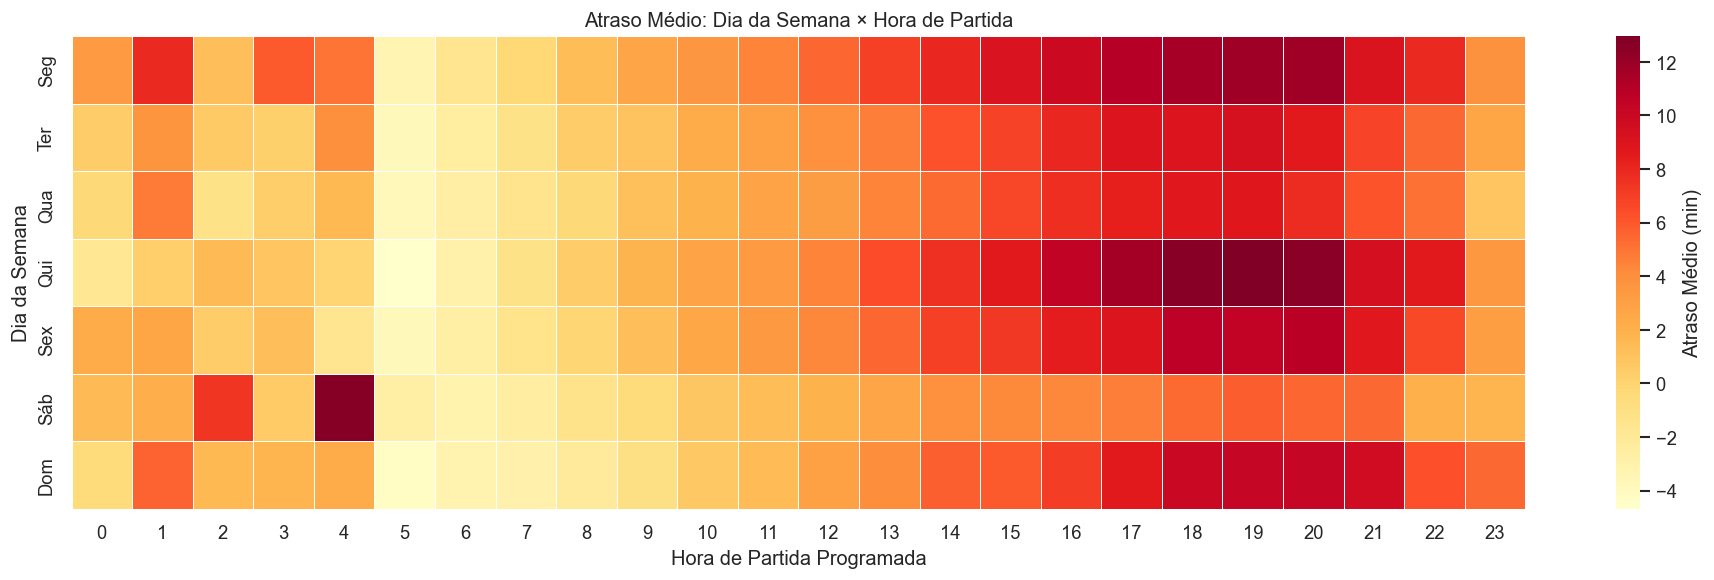

In [12]:
heatmap_data = flights.pivot_table(
    values="ARRIVAL_DELAY", index="DAY_OF_WEEK", columns="DEP_HOUR", aggfunc="mean"
)
heatmap_data.index = [day_map.get(i, i) for i in heatmap_data.index]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap="YlOrRd", ax=ax, cbar_kws={"label": "Atraso Médio (min)"},
            linewidths=0.3)
ax.set_title("Atraso Médio: Dia da Semana × Hora de Partida")
ax.set_xlabel("Hora de Partida Programada")
ax.set_ylabel("Dia da Semana")
plt.tight_layout()
plt.savefig("../outputs/figures/eda_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 1.10 Matriz de Correlação

Analisamos as correlações de Pearson entre as variáveis numéricas principais para identificar relações lineares fortes.

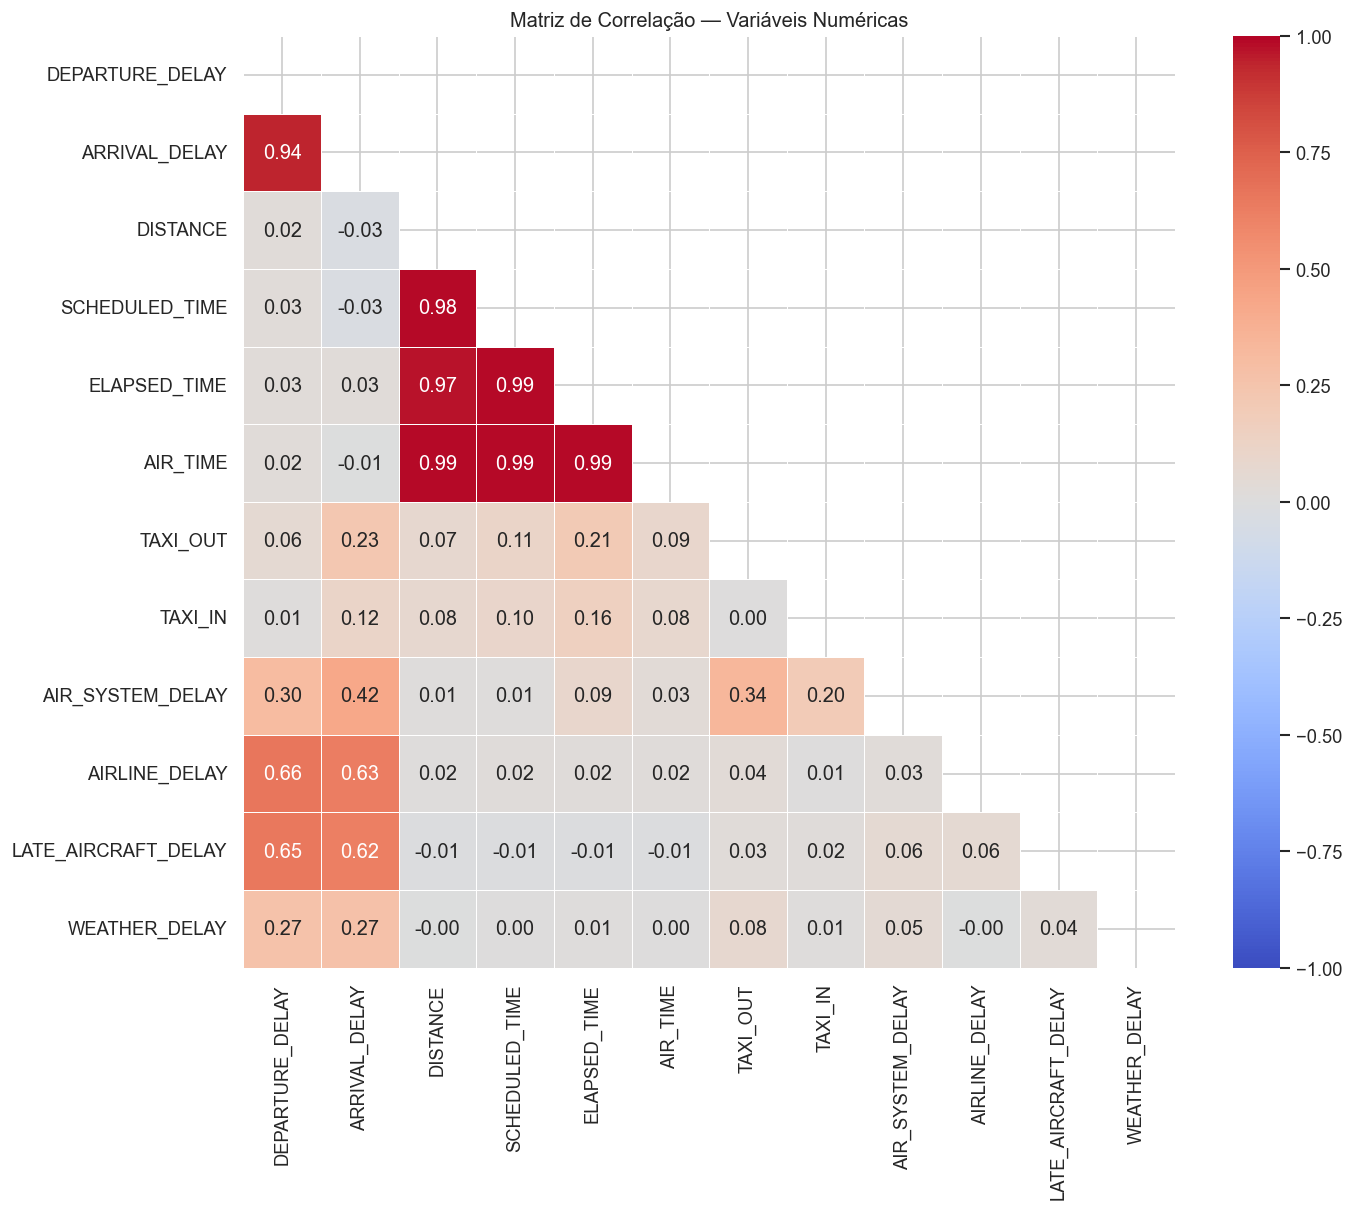

In [13]:
corr_cols = [
    "DEPARTURE_DELAY", "ARRIVAL_DELAY", "DISTANCE", "SCHEDULED_TIME",
    "ELAPSED_TIME", "AIR_TIME", "TAXI_OUT", "TAXI_IN",
    "AIR_SYSTEM_DELAY", "AIRLINE_DELAY", "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY"
]
corr = flights[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            ax=ax, vmin=-1, vmax=1, linewidths=0.5, square=True)
ax.set_title("Matriz de Correlação — Variáveis Numéricas")
plt.tight_layout()
plt.savefig("../outputs/figures/eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## 1.11 Análise de Outliers com Boxplots

Boxplots das principais variáveis de tempo e atraso para visualizar a dispersão e a presença de outliers.

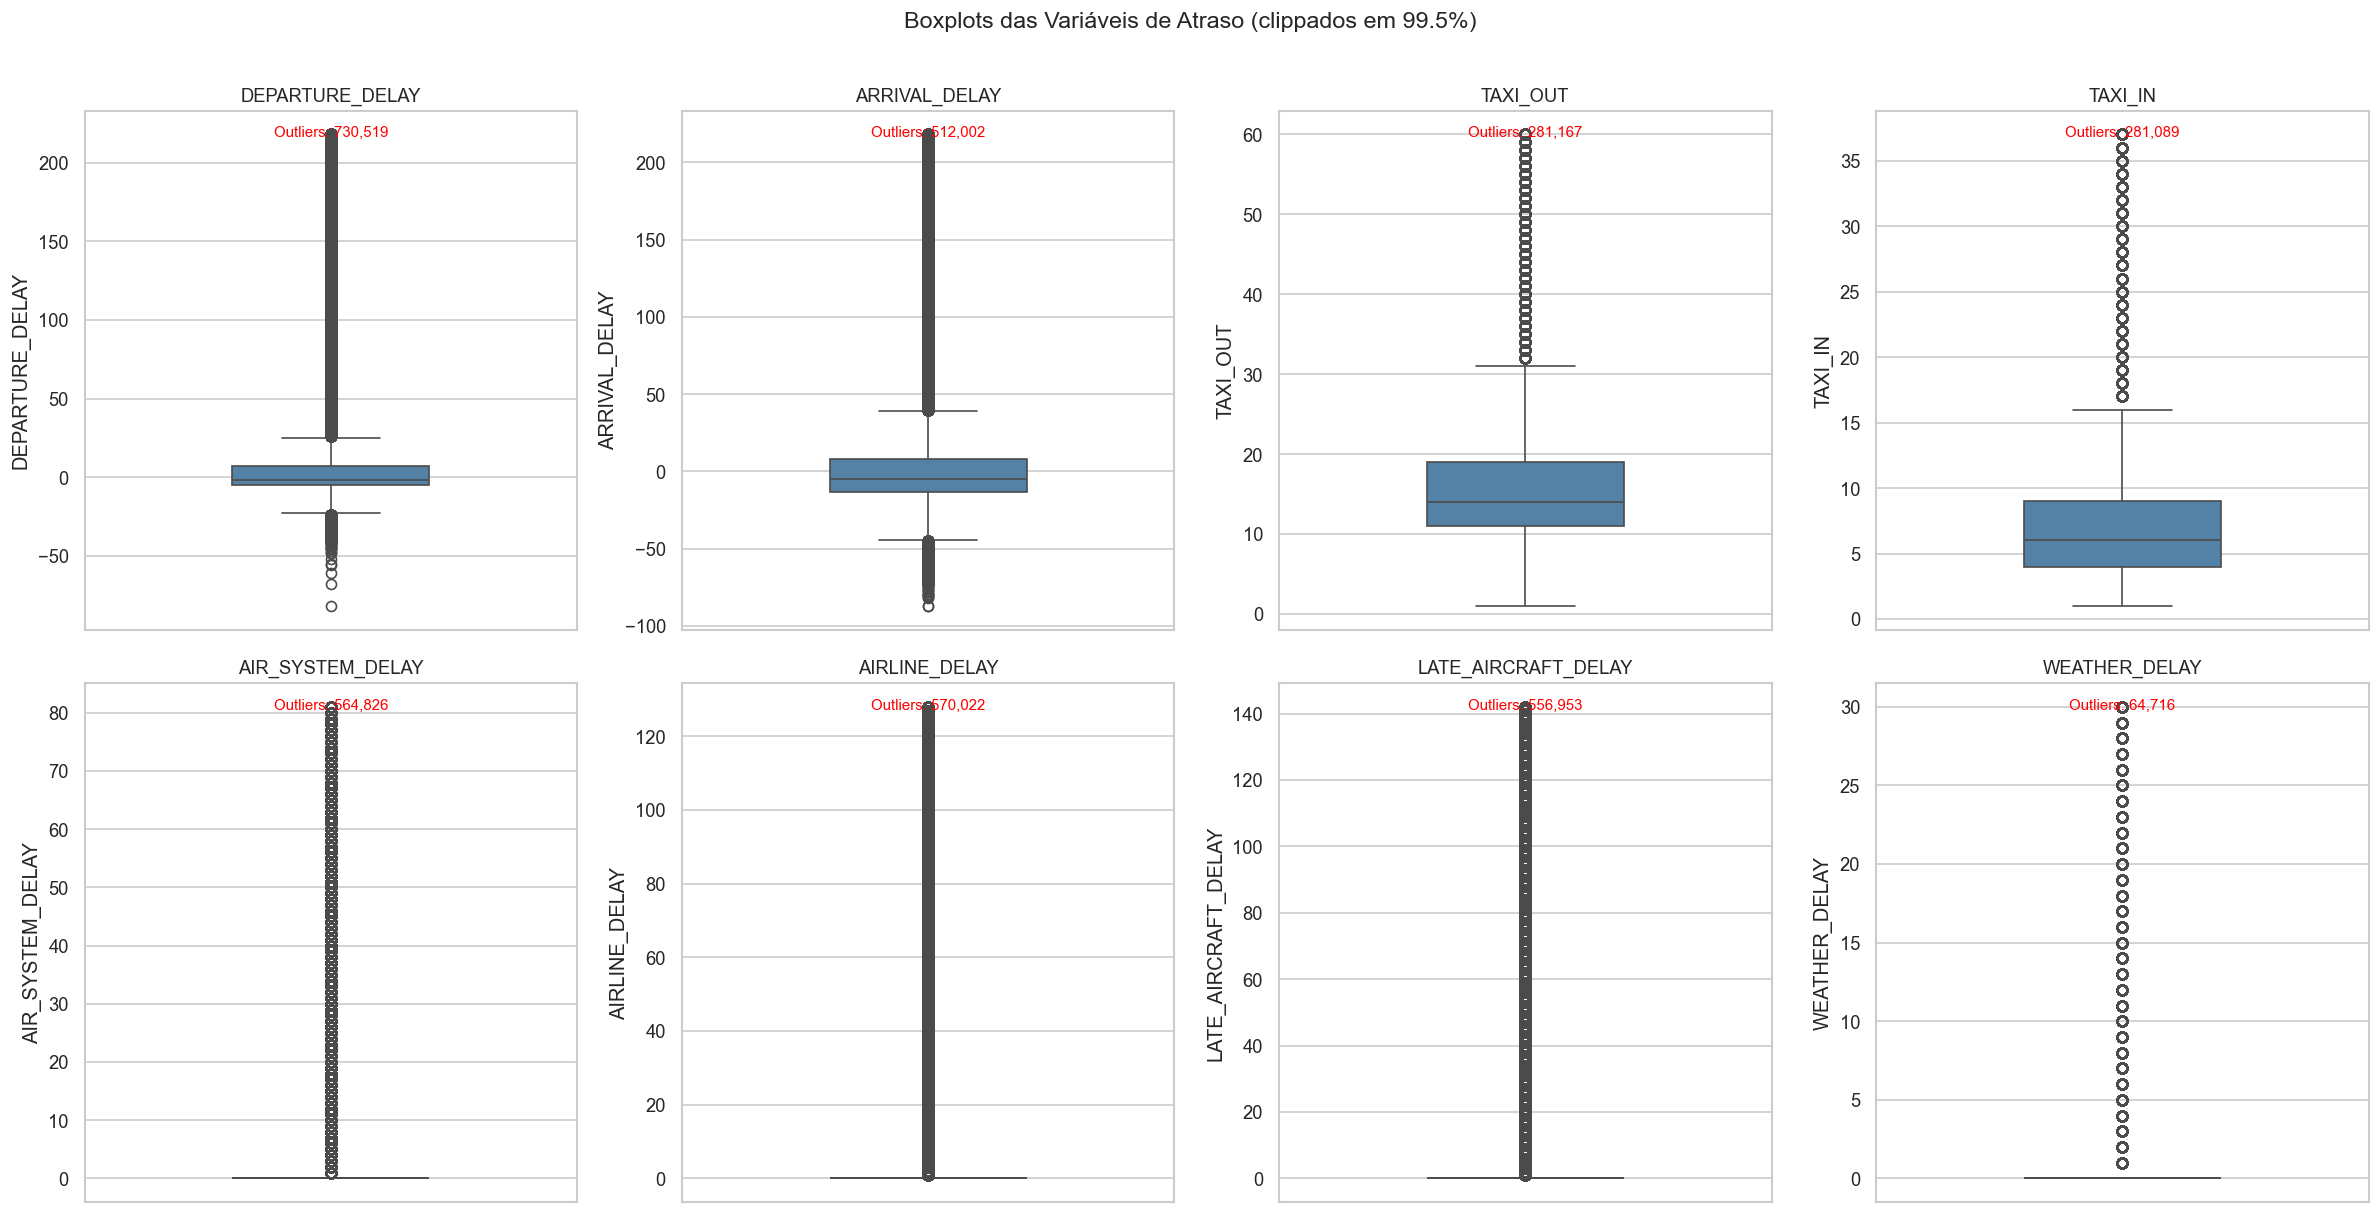

In [14]:
box_cols = ["DEPARTURE_DELAY", "ARRIVAL_DELAY", "TAXI_OUT", "TAXI_IN",
            "AIR_SYSTEM_DELAY", "AIRLINE_DELAY", "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(box_cols):
    data = flights[col].dropna()
    # Limitar para visualização (clipar nos 99.5% para não distorcer o gráfico)
    upper = data.quantile(0.995)
    sns.boxplot(y=data.clip(upper=upper), ax=axes[i], color="steelblue", width=0.4)
    axes[i].set_title(col, fontsize=11)

    # Calcular outliers IQR
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((data < Q1 - 1.5 * IQR) | (data > Q3 + 1.5 * IQR)).sum()
    axes[i].annotate(f"Outliers: {n_outliers:,}", xy=(0.5, 0.95),
                     xycoords="axes fraction", ha="center", fontsize=9, color="red")

plt.suptitle("Boxplots das Variáveis de Atraso (clippados em 99.5%)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/figures/eda_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

## 1.12 Composição dos Tipos de Atraso

O dataset detalha a causa dos atrasos em 5 categorias: companhia aérea, aeronave atrasada, sistema aéreo (NAS), clima e segurança. Qual a contribuição média de cada uma?

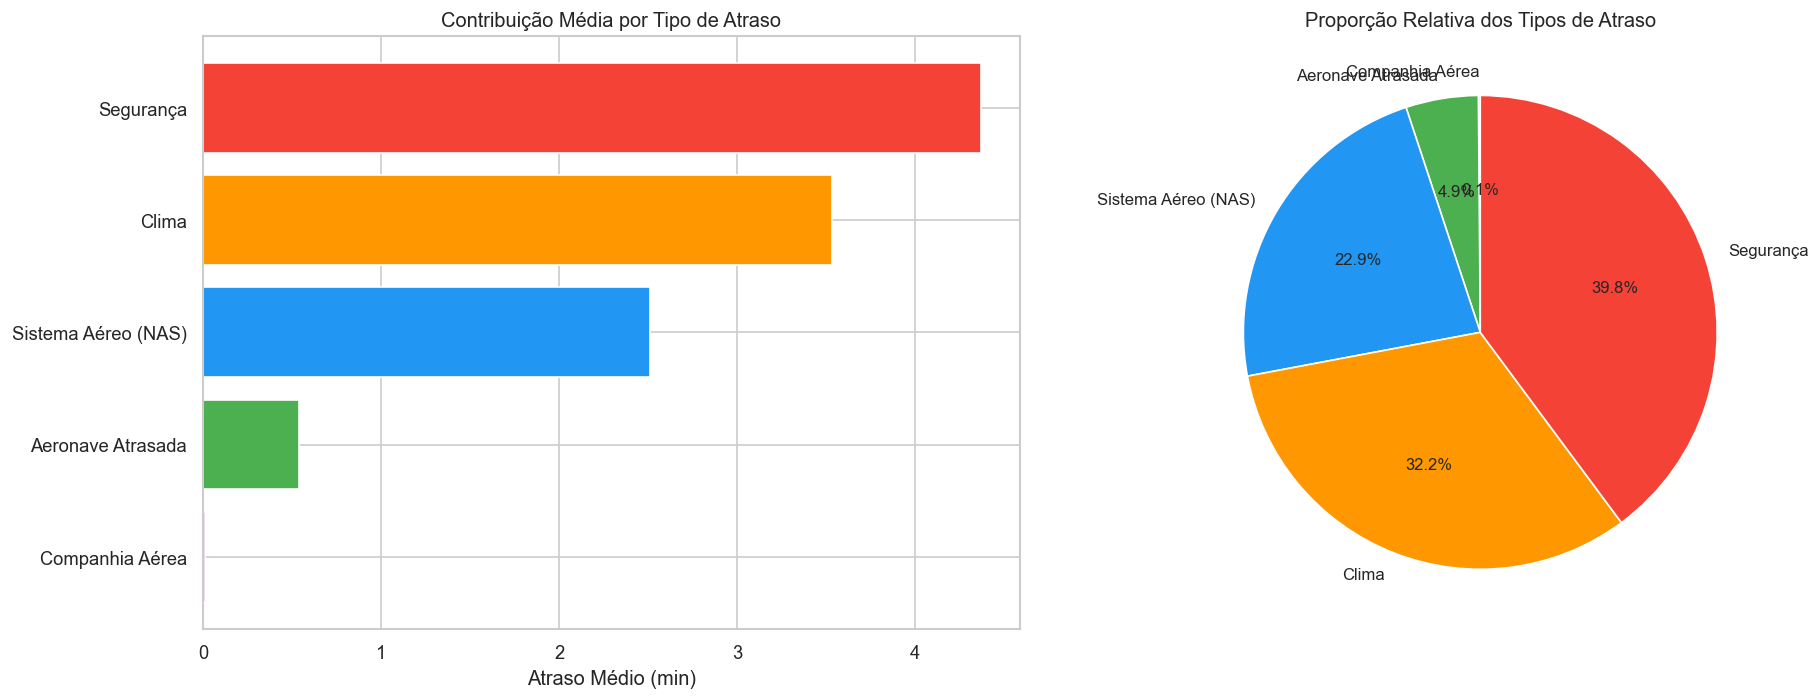

Atraso médio por tipo (minutos):
  Companhia Aérea: 0.01
  Aeronave Atrasada: 0.54
  Sistema Aéreo (NAS): 2.51
  Clima: 3.53
  Segurança: 4.37


In [15]:
delay_types = ["AIRLINE_DELAY", "LATE_AIRCRAFT_DELAY", "AIR_SYSTEM_DELAY",
               "WEATHER_DELAY", "SECURITY_DELAY"]
delay_labels = ["Companhia Aérea", "Aeronave Atrasada", "Sistema Aéreo (NAS)",
                "Clima", "Segurança"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Média por tipo de atraso
delay_means = flights[delay_types].mean().sort_values(ascending=True)
colors = ["#9C27B0", "#4CAF50", "#2196F3", "#FF9800", "#F44336"]
axes[0].barh(delay_labels, delay_means.values, color=colors)
axes[0].set_xlabel("Atraso Médio (min)")
axes[0].set_title("Contribuição Média por Tipo de Atraso")

# Pizza: proporção relativa
axes[1].pie(delay_means.values, labels=delay_labels, autopct="%1.1f%%",
            colors=colors, startangle=90, textprops={"fontsize": 10})
axes[1].set_title("Proporção Relativa dos Tipos de Atraso")

plt.tight_layout()
plt.savefig("../outputs/figures/eda_delay_types.png", dpi=150, bbox_inches="tight")
plt.show()

print("Atraso médio por tipo (minutos):")
for label, val in zip(delay_labels, delay_means.values):
    print(f"  {label}: {val:.2f}")

## 1.13 Features Derivadas: Período do Dia, Estação, Feriados e Fim de Semana

Analisamos o impacto das variáveis criadas no feature engineering.

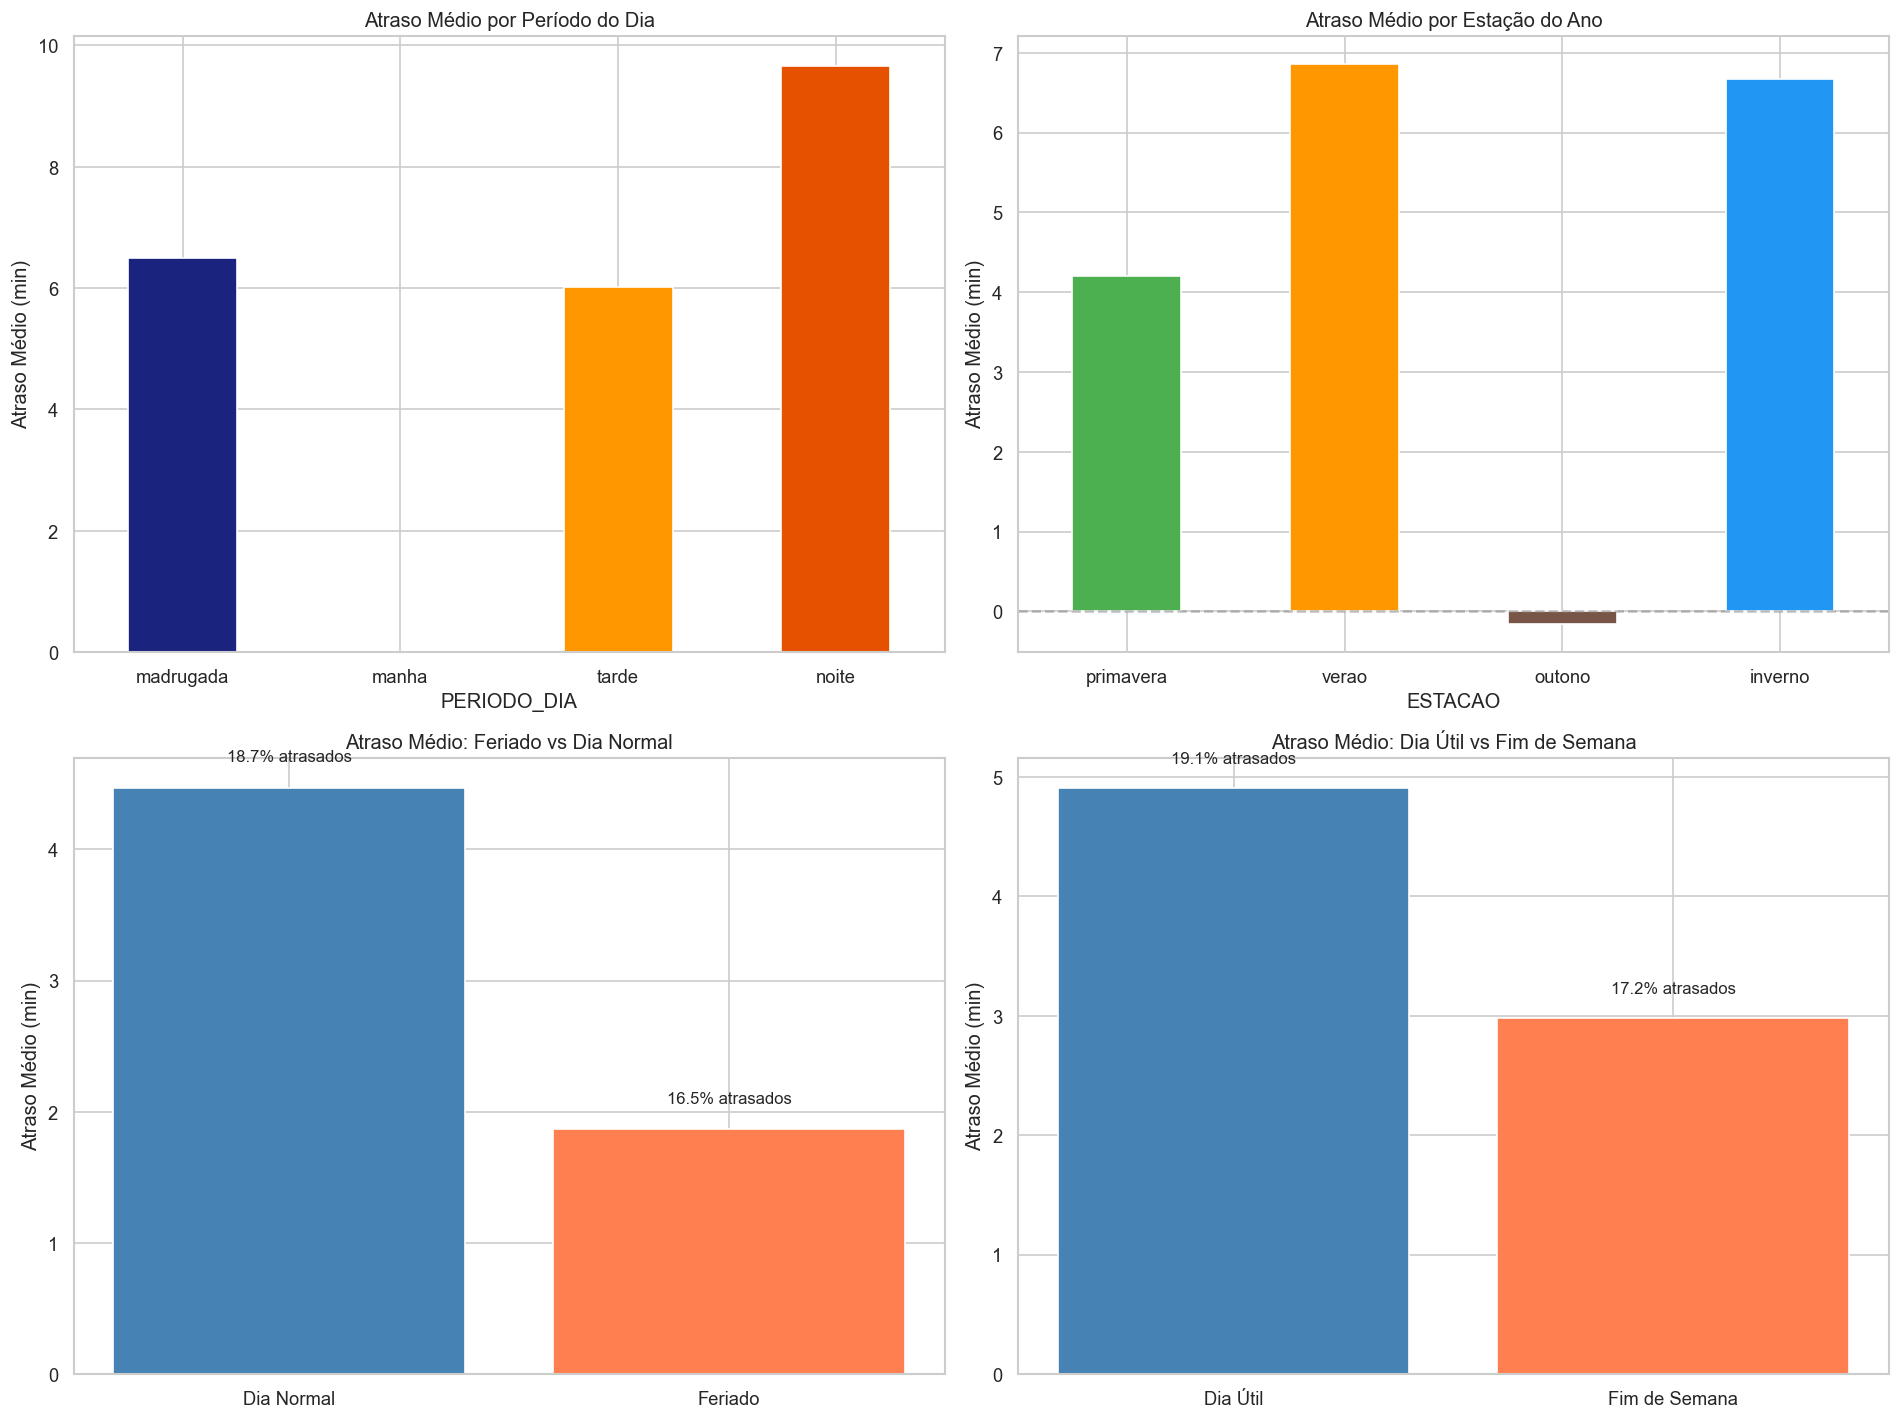

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Atraso por período do dia
periodo_order = ["madrugada", "manha", "tarde", "noite"]
periodo_stats = flights.groupby("PERIODO_DIA")["ARRIVAL_DELAY"].mean().reindex(periodo_order)
periodo_stats.plot(kind="bar", ax=axes[0, 0],
                   color=["#1a237e", "#ffc107", "#ff9800", "#e65100"], rot=0)
axes[0, 0].set_ylabel("Atraso Médio (min)")
axes[0, 0].set_title("Atraso Médio por Período do Dia")
axes[0, 0].axhline(0, color="gray", linestyle="--", alpha=0.5)

# Atraso por estação
estacao_order = ["primavera", "verao", "outono", "inverno"]
estacao_stats = flights.groupby("ESTACAO")["ARRIVAL_DELAY"].mean().reindex(estacao_order)
estacao_stats.plot(kind="bar", ax=axes[0, 1],
                   color=["#4CAF50", "#FF9800", "#795548", "#2196F3"], rot=0)
axes[0, 1].set_ylabel("Atraso Médio (min)")
axes[0, 1].set_title("Atraso Médio por Estação do Ano")
axes[0, 1].axhline(0, color="gray", linestyle="--", alpha=0.5)

# Feriados
holiday_labels = {0: "Dia Normal", 1: "Feriado"}
holiday_stats = flights.groupby("IS_HOLIDAY").agg(
    media_atraso=("ARRIVAL_DELAY", "mean"),
    pct_atrasados=("IS_DELAYED", "mean"),
)
bars = axes[1, 0].bar([holiday_labels[i] for i in holiday_stats.index],
                       holiday_stats["media_atraso"], color=["steelblue", "coral"])
axes[1, 0].set_ylabel("Atraso Médio (min)")
axes[1, 0].set_title("Atraso Médio: Feriado vs Dia Normal")
for bar, pct in zip(bars, holiday_stats["pct_atrasados"]):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                    f"{pct*100:.1f}% atrasados", ha="center", fontsize=10)

# Fim de semana
weekend_labels = {0: "Dia Útil", 1: "Fim de Semana"}
weekend_stats = flights.groupby("IS_WEEKEND").agg(
    media_atraso=("ARRIVAL_DELAY", "mean"),
    pct_atrasados=("IS_DELAYED", "mean"),
)
bars = axes[1, 1].bar([weekend_labels[i] for i in weekend_stats.index],
                       weekend_stats["media_atraso"], color=["steelblue", "coral"])
axes[1, 1].set_ylabel("Atraso Médio (min)")
axes[1, 1].set_title("Atraso Médio: Dia Útil vs Fim de Semana")
for bar, pct in zip(bars, weekend_stats["pct_atrasados"]):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                    f"{pct*100:.1f}% atrasados", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../outputs/figures/eda_features_derivadas.png", dpi=150, bbox_inches="tight")
plt.show()

## 1.14 Análise Bivariada: Distância vs Atraso

Existe relação entre a distância do voo e o atraso?

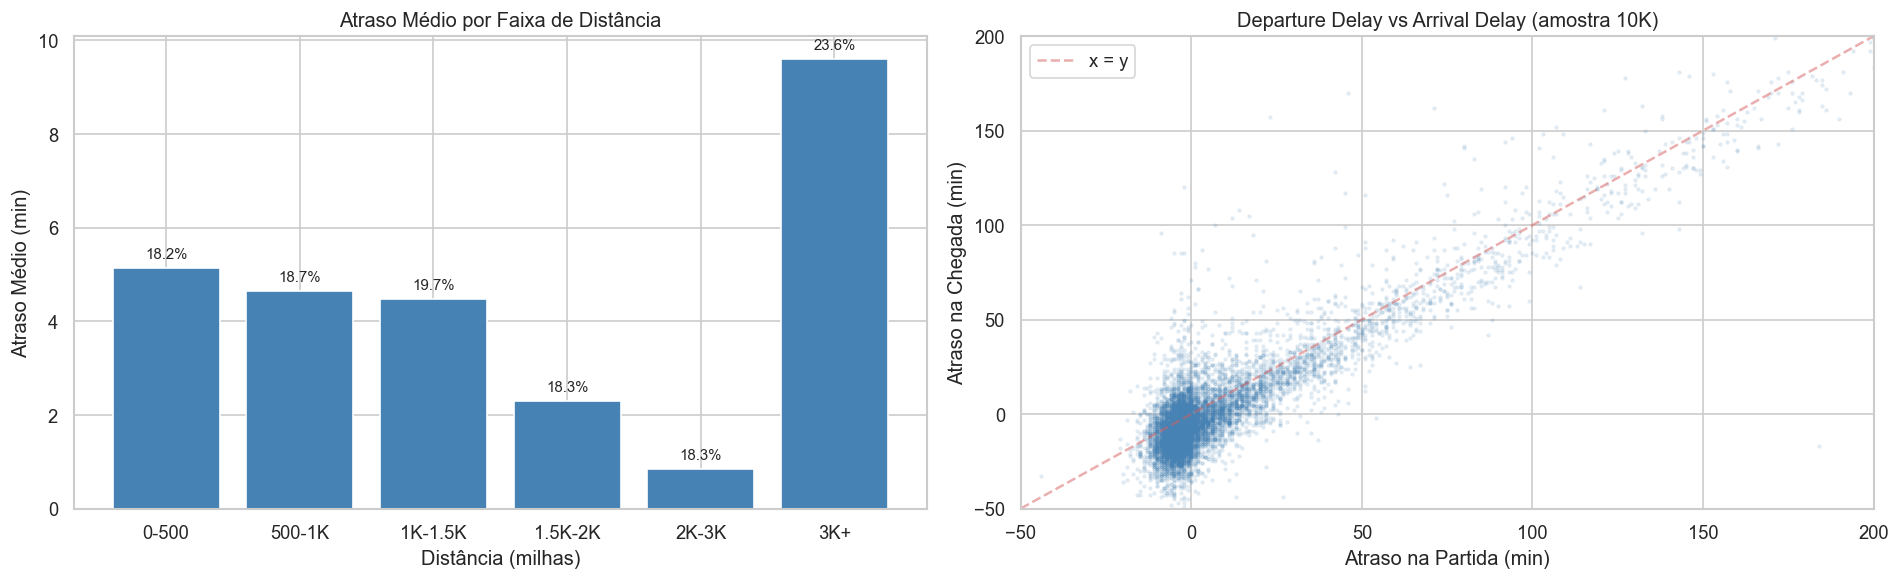

In [17]:
# Agrupar por faixa de distância
flights["DIST_BIN"] = pd.cut(flights["DISTANCE"],
                              bins=[0, 500, 1000, 1500, 2000, 3000, 6000],
                              labels=["0-500", "500-1K", "1K-1.5K", "1.5K-2K", "2K-3K", "3K+"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Atraso médio por faixa
dist_stats = flights.groupby("DIST_BIN", observed=True).agg(
    media_atraso=("ARRIVAL_DELAY", "mean"),
    pct_atrasados=("IS_DELAYED", "mean"),
    total=("FLIGHT_NUMBER", "count"),
)
bars = axes[0].bar(dist_stats.index.astype(str), dist_stats["media_atraso"], color="steelblue")
axes[0].set_xlabel("Distância (milhas)")
axes[0].set_ylabel("Atraso Médio (min)")
axes[0].set_title("Atraso Médio por Faixa de Distância")
for bar, pct in zip(bars, dist_stats["pct_atrasados"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f"{pct*100:.1f}%", ha="center", fontsize=9)
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.5)

# Scatter: Departure Delay vs Arrival Delay (amostra)
sample = flights.sample(n=10000, random_state=42)
axes[1].scatter(sample["DEPARTURE_DELAY"], sample["ARRIVAL_DELAY"],
                alpha=0.1, s=3, color="steelblue")
axes[1].plot([-50, 200], [-50, 200], "r--", alpha=0.5, label="x = y")
axes[1].set_xlim(-50, 200)
axes[1].set_ylim(-50, 200)
axes[1].set_xlabel("Atraso na Partida (min)")
axes[1].set_ylabel("Atraso na Chegada (min)")
axes[1].set_title("Departure Delay vs Arrival Delay (amostra 10K)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/figures/eda_bivariate.png", dpi=150, bbox_inches="tight")
plt.show()

flights.drop(columns=["DIST_BIN"], inplace=True)

## 1.15 Análise por Estado

Agrupamos os atrasos por estado de origem para identificar regiões geográficas mais críticas.

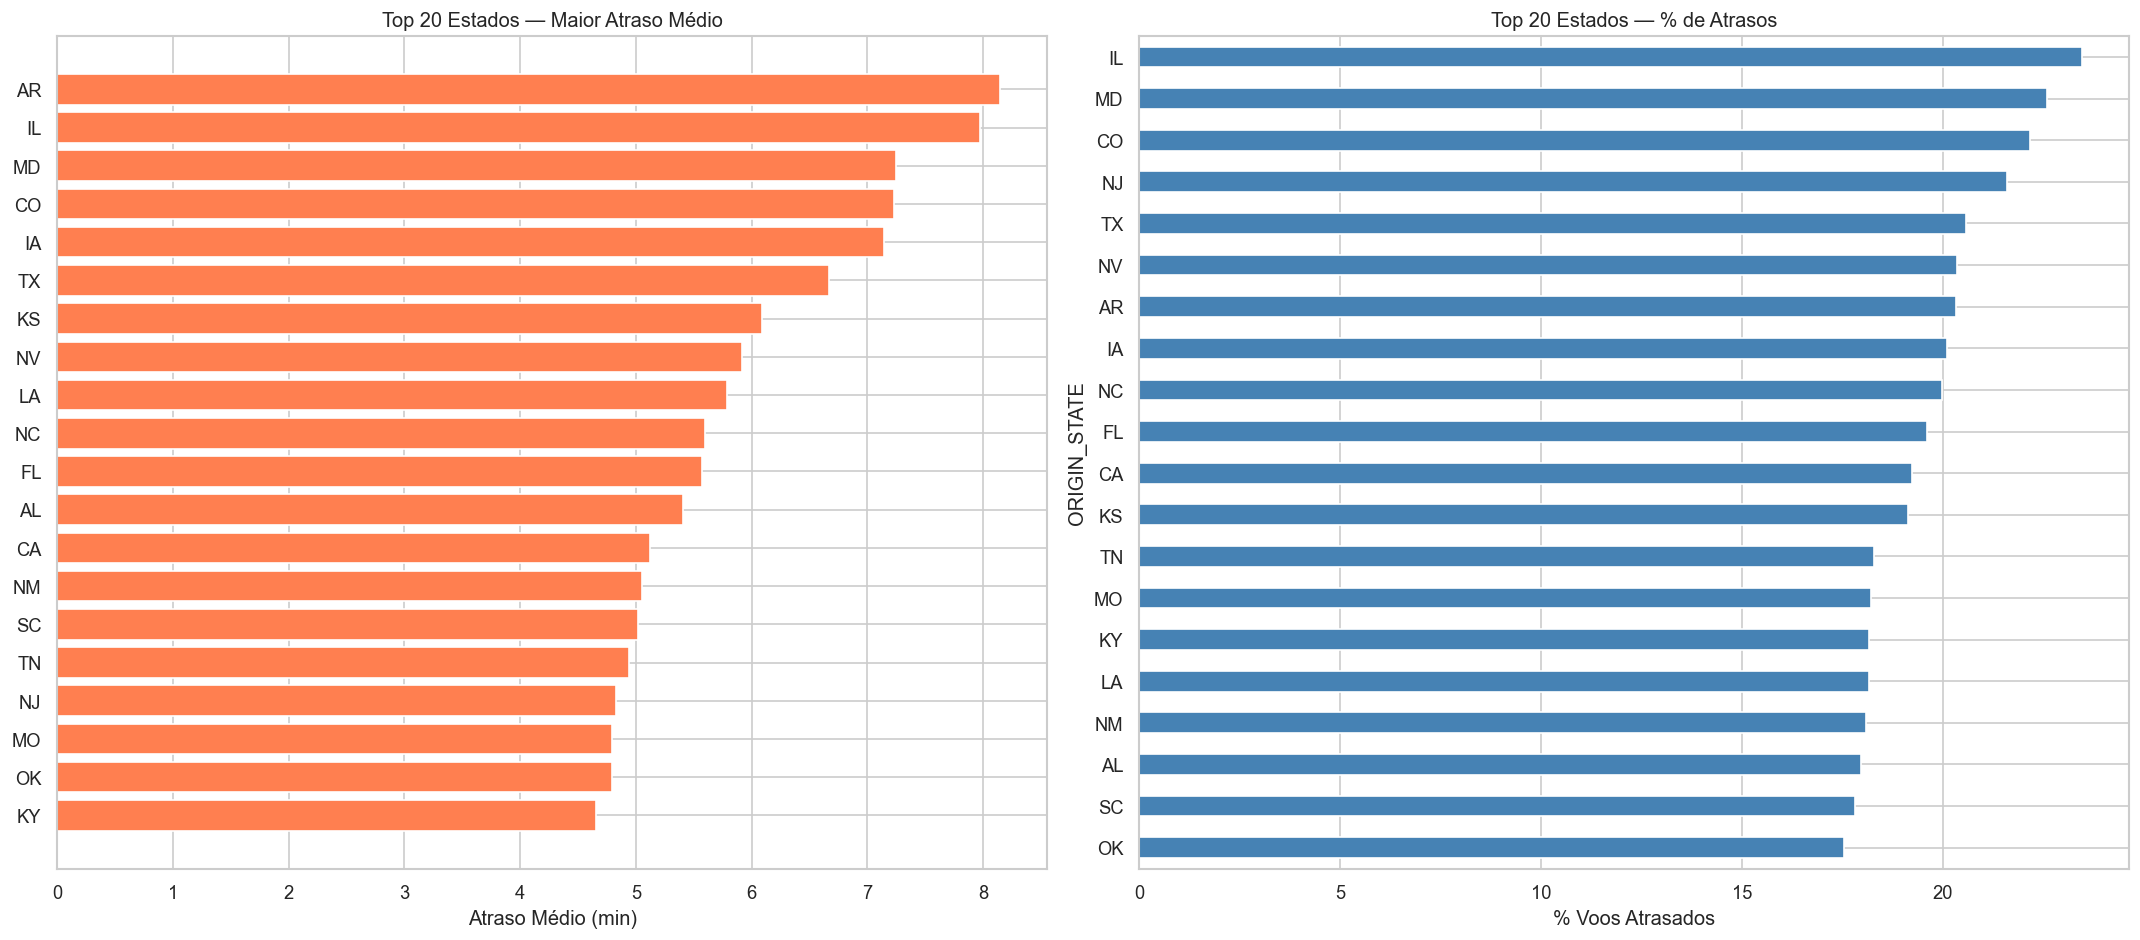


Estados analisados: 44

Top 5 piores estados (atraso médio):
  AR: 8.1 min (20.3% atrasados, 21,923.0 voos)
  IL: 8.0 min (23.5% atrasados, 369,479.0 voos)
  MD: 7.2 min (22.6% atrasados, 84,329.0 voos)
  CO: 7.2 min (22.2% atrasados, 212,126.0 voos)
  IA: 7.1 min (20.1% atrasados, 16,728.0 voos)


In [18]:
state_stats = (
    flights.groupby("ORIGIN_STATE")
    .agg(
        media_atraso=("ARRIVAL_DELAY", "mean"),
        pct_atrasados=("IS_DELAYED", "mean"),
        total_voos=("FLIGHT_NUMBER", "count"),
    )
    .query("total_voos >= 10000")
    .sort_values("media_atraso", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

top_states = state_stats.head(20)
axes[0].barh(top_states.index[::-1], top_states["media_atraso"].values[::-1], color="coral")
axes[0].set_xlabel("Atraso Médio (min)")
axes[0].set_title("Top 20 Estados — Maior Atraso Médio")

(state_stats["pct_atrasados"].head(20) * 100).sort_values().plot(
    kind="barh", ax=axes[1], color="steelblue"
)
axes[1].set_xlabel("% Voos Atrasados")
axes[1].set_title("Top 20 Estados — % de Atrasos")

plt.tight_layout()
plt.savefig("../outputs/figures/eda_states.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nEstados analisados: {len(state_stats)}")
print(f"\nTop 5 piores estados (atraso médio):")
for state, row in state_stats.head(5).iterrows():
    print(f"  {state}: {row['media_atraso']:.1f} min ({row['pct_atrasados']*100:.1f}% atrasados, {row['total_voos']:,} voos)")

## 1.16 Mapa Geográfico de Atrasos por Aeroporto

Utilizamos Plotly para criar um mapa interativo mostrando a localização dos aeroportos, o volume de voos (tamanho dos pontos) e o atraso médio (cor). Isso permite uma visão geoespacial imediata dos gargalos na malha aérea.

In [19]:
import plotly.express as px

airport_geo = (
    flights.groupby("ORIGIN_AIRPORT")
    .agg(
        media_atraso=("ARRIVAL_DELAY", "mean"),
        pct_atrasados=("IS_DELAYED", "mean"),
        total_voos=("FLIGHT_NUMBER", "count"),
        lat=("ORIGIN_LAT", "first"),
        lon=("ORIGIN_LON", "first"),
    )
    .query("total_voos >= 1000")
    .reset_index()
)

fig_map = px.scatter_geo(
    airport_geo,
    lat="lat", lon="lon",
    size="total_voos",
    color="media_atraso",
    hover_name="ORIGIN_AIRPORT",
    hover_data={"total_voos": ":,", "pct_atrasados": ":.1%", "media_atraso": ":.1f"},
    color_continuous_scale="RdYlGn_r",
    size_max=25,
    title="Mapa de Atrasos Médios por Aeroporto (EUA 2015)",
    scope="usa",
)
fig_map.update_layout(
    geo=dict(showland=True, landcolor="lightgray"),
    height=600, width=1000,
)
fig_map.write_html("../outputs/figures/mapa_atrasos.html")
fig_map.show()

print(f"Aeroportos no mapa: {len(airport_geo)} (≥1000 voos)")
print(f"Atraso médio global: {airport_geo['media_atraso'].mean():.1f} min")

Aeroportos no mapa: 297 (≥1000 voos)
Atraso médio global: 3.3 min


## 1.17 Features de Congestionamento

Analisamos as features derivadas de congestionamento operacional (`FLIGHTS_SAME_HOUR_ORIGIN` e `ROUTE_POPULARITY`) — indicadores proxy de sobrecarga que podem impactar atrasos.

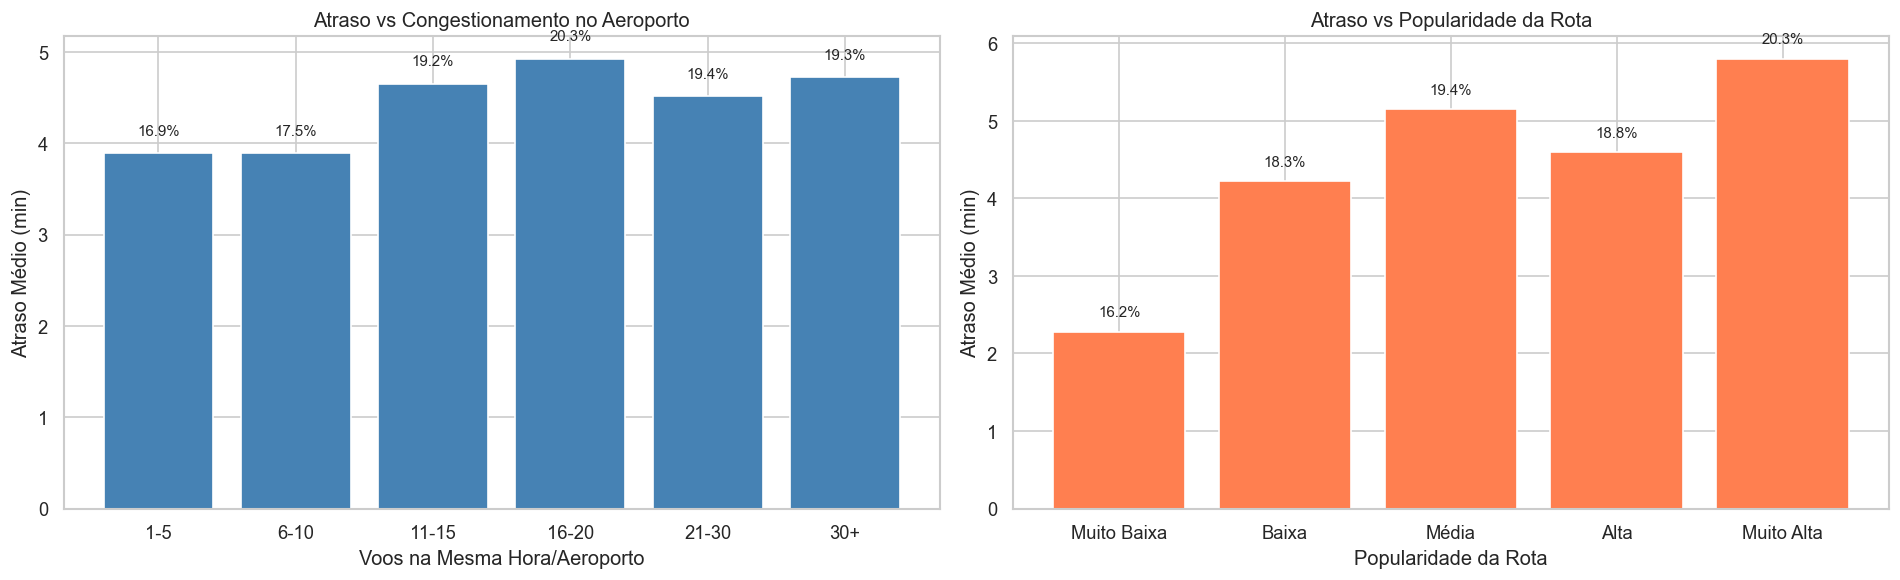

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Congestionamento por hora
congestion_bins = pd.cut(flights["FLIGHTS_SAME_HOUR_ORIGIN"],
                          bins=[0, 5, 10, 15, 20, 30, 100],
                          labels=["1-5", "6-10", "11-15", "16-20", "21-30", "30+"])
cong_stats = flights.groupby(congestion_bins, observed=True).agg(
    media_atraso=("ARRIVAL_DELAY", "mean"),
    pct_atrasados=("IS_DELAYED", "mean"),
)
bars = axes[0].bar(cong_stats.index.astype(str), cong_stats["media_atraso"], color="steelblue")
axes[0].set_xlabel("Voos na Mesma Hora/Aeroporto")
axes[0].set_ylabel("Atraso Médio (min)")
axes[0].set_title("Atraso vs Congestionamento no Aeroporto")
for bar, pct in zip(bars, cong_stats["pct_atrasados"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f"{pct*100:.1f}%", ha="center", fontsize=9)

# Popularidade da rota
route_bins = pd.qcut(flights["ROUTE_POPULARITY"], q=5,
                       labels=["Muito Baixa", "Baixa", "Média", "Alta", "Muito Alta"])
route_stats = flights.groupby(route_bins, observed=True).agg(
    media_atraso=("ARRIVAL_DELAY", "mean"),
    pct_atrasados=("IS_DELAYED", "mean"),
)
bars = axes[1].bar(route_stats.index.astype(str), route_stats["media_atraso"], color="coral")
axes[1].set_xlabel("Popularidade da Rota")
axes[1].set_ylabel("Atraso Médio (min)")
axes[1].set_title("Atraso vs Popularidade da Rota")
for bar, pct in zip(bars, route_stats["pct_atrasados"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f"{pct*100:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/eda_congestion.png", dpi=150, bbox_inches="tight")
plt.show()

## 1.18 Resumo dos Insights e Próximos Passos

Com base na exploração realizada, destacamos os principais achados:

- **Proporção de atrasos**: Aproximadamente 1 em cada 4-5 voos sofre atraso >= 15 minutos na chegada — classes desbalanceadas.
- **Companhias aéreas**: Grande variação no desempenho — algumas companhias têm o dobro da taxa de atraso. Companhias regionais tendem a atrasar mais.
- **Aeroportos críticos**: ORD (Chicago), SFO (San Francisco) e EWR (Newark) concentram atrasos pelo alto congestionamento.
- **Horários críticos**: Atrasos se acumulam ao longo do dia, pico no final da tarde/noite (17h-21h). Manhã tem atrasos menores — efeito cascata.
- **Sazonalidade**: Meses de verão (Jun/Jul) e festas (Dezembro) concentram maiores atrasos.
- **Composição do atraso**: Aeronave atrasada (late aircraft) e companhia aérea são as causas dominantes. Clima e segurança representam fração menor.
- **Feriados**: Efeito modesto mas consistente — atraso ligeiramente maior.
- **Correlação forte**: DEPARTURE_DELAY e ARRIVAL_DELAY altamente correlacionados (~0.94).
- **Outliers**: Muitos outliers (atrasos >2h), podem impactar regressão.
- **Distância**: Sem relação linear clara com atraso — fatores operacionais são mais determinantes.
- **Estados**: Estados com hubs movimentados (IL, NY, NJ) apresentam maiores atrasos.
- **Congestionamento**: Número de voos simultâneos correlaciona-se positivamente com atrasos — justifica inclusão como feature.
- **Mapa geográfico**: Concentração de atrasos no Nordeste (NY, NJ, Boston) e hubs do Midwest (Chicago).

### Próximos Passos

1. **Modelagem Supervisionada**: Classificação e Regressão com cross-validation (3-fold)
2. **Modelagem Não Supervisionada**: KMeans + DBSCAN + PCA + Detecção de Anomalias (Isolation Forest)
3. **Feature Engineering**: Avaliar impacto das features de congestionamento e proximidade de feriados

Estes insights guiarão a seleção de features e a interpretação dos resultados nas próximas etapas.